# Phase 2 & 3: Data Cleaning, Preprocessing & Exploratory Data Analysis
## Fitness App Market Analytics (Google Play Store)

**Business problem:** Identify what separates high-performing, trusted fitness
apps from the rest of a crowded market, to inform investment/partnership
decisions for a digital wellness platform.

This notebook:
1. Loads the raw scraped data (`raw_apps.csv`, `raw_reviews.csv`)
2. Cleans and preprocesses it into an analysis-ready table
3. Engineers useful features (price band, rating tier, install tier, app age, etc.)
4. Explores the data through summary statistics and visualizations
5. Saves the cleaned datasets for modeling in the next notebook


## 1. Setup & Load Raw Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

apps = pd.read_csv('../data/raw/raw_apps.csv')
reviews = pd.read_csv('../data/raw/raw_reviews.csv')

print(f"Raw apps shape: {apps.shape}")
print(f"Raw reviews shape: {reviews.shape}")
apps.head(3)


Raw apps shape: (1197, 18)
Raw reviews shape: (34042, 8)


,app_id,title,developer,category,score,ratings,installs,minInstalls,price,free,containsAds,offersIAP,size,androidVersion,released,updated,contentRating,description
0,com.slumberaid.snoretracker,SlumberAid：Sleep Snore Tracker,lJX.Studio,Health & Fitness,3.333333,30.0,"1,000+",1000,0.00,True,False,False,NaN,NaN,"Jan 16, 2025",NaN,Everyone,Do you know how well you sleep every night? Do...
1,com.spotlightsix.zentimerlite2,Insight Timer - Meditation App,Insight Network Inc,Health & Fitness,4.707091,259577.0,"10,000,000+",10000000,0.00,True,False,True,NaN,NaN,"Dec 15, 2010",1.783433e+09,Everyone,* Apps of the Year Winner - TIME magazine and ...
2,com.photoandvideo.recoveryfilepro,DS PRO - Recover All Deleted,Detective Studio,Tools,4.290000,4923.0,"100,000+",100000,5.99,False,False,False,NaN,NaN,"Jun 18, 2020",1.736940e+09,Everyone,🔥 The app works more efficiently in the Pro ve...


## 2. Initial Data Quality Check

Before cleaning, let's understand what we're working with — missing values,
data types, and duplicates.

In [106]:
print("Missing values per column:")
print(apps.isna().sum())
print()
print("Data types:")
print(apps.dtypes)


Missing values per column:
app_id               0
title                0
developer            0
category             0
score              259
ratings            259
installs             0
minInstalls          0
price                0
free                 0
containsAds          0
offersIAP            0
size              1197
androidVersion    1197
released             7
updated            320
contentRating        0
description          0
dtype: int64

Data types:
app_id             object
title              object
developer          object
category           object
score             float64
ratings           float64
installs           object
minInstalls         int64
price             float64
free                 bool
containsAds          bool
offersIAP            bool
size              float64
androidVersion    float64
released           object
updated           float64
contentRating      object
description        object
dtype: object


In [107]:
print(f"Duplicate app_ids: {apps['app_id'].duplicated().sum()}")
print(f"Duplicate titles: {apps['title'].duplicated().sum()}")


Duplicate app_ids: 0
Duplicate titles: 13


## 3. Data Cleaning & Preprocessing

**Steps taken and why:**

1. **Drop `size` and `androidVersion`** — these came back 100% empty from the
   scraper for this app category, so they carry no information.
2. **Drop the string `installs` column** (e.g. `"1,000,000+"`) — it's
   redundant with the already-clean numeric `minInstalls` column.
3. **Drop rows with missing `score`/`ratings`** — these are apps too new or
   too small to have a public rating yet. Since our analysis is centered on
   what drives ratings and trust, apps with no rating can't contribute to
   that question. This removes ~22% of rows but keeps the remaining data
   meaningful for rating-based analysis.
4. **Convert timestamps** — `updated` (Unix time) and `released` (string)
   are converted into proper datetime columns.


In [108]:
# Drop empty/redundant columns
apps_clean = apps.drop(columns=['size', 'androidVersion', 'installs'])

# Drop apps with no public rating yet
before = len(apps_clean)
apps_clean = apps_clean.dropna(subset=['score', 'ratings']).copy()
after = len(apps_clean)
print(f"Dropped {before - after} unrated apps ({(before-after)/before*100:.1f}%)")
print(f"Remaining apps: {after}")


Dropped 259 unrated apps (21.6%)
Remaining apps: 938


In [ ]:
def clean_text(text):
    if not isinstance(text, str):
        return text
    text = re.sub(r'<[^>]+>', ' ', text)          # remove HTML tags like <b>, <br>, <i>
    text = re.sub(r'[^\x00-\x7F]+', '', text)     # remove garbled/mojibake characters
    text = re.sub(r'\s+', ' ', text)               # collapse multiple spaces/newlines
    return text.strip()

In [110]:
# Convert timestamps to proper dates
apps_clean['updated_date'] = pd.to_datetime(apps_clean['updated'], unit='s', errors='coerce')
apps_clean['released_date'] = pd.to_datetime(apps_clean['released'], errors='coerce')

apps_clean = apps_clean.drop(columns=['updated', 'released'])

print(f"Missing updated_date: {apps_clean['updated_date'].isna().sum()}")
print(f"Missing released_date: {apps_clean['released_date'].isna().sum()}")


Missing updated_date: 82
Missing released_date: 4


In [111]:
# Clean text fields - strip whitespace, remove line breaks from description
apps_clean['title'] = apps_clean['title'].str.strip()
apps_clean['developer'] = apps_clean['developer'].str.strip()
apps_clean['description'] = apps_clean['description'].fillna('').str.replace(r'\s+', ' ', regex=True).str.strip()
apps_clean['description'] = apps_clean['description'].apply(clean_text)

## 4. Feature Engineering

Creating business-relevant features that will support both EDA and modeling:

- **`price_band`** — Free vs. Paid (price is heavily skewed toward free, so a
  simple split is most meaningful)
- **`rating_tier`** — categorical bucket of app quality (Poor / Average / Good / Excellent)
- **`install_tier`** — categorical bucket of app reach (Niche / Growing / Popular / Mega)
- **`days_since_update`** — how long since the app was last updated (a proxy for active maintenance)
- **`app_age_days`** — how long the app has existed on the store
- **`description_length`** — character count of the app description (proxy for how much detail/marketing effort went in)
- **`category_grouped`** — simplifies the long tail of categories into the top categories + "Other"


In [112]:
# Price band
apps_clean['price_band'] = np.where(apps_clean['price'] > 0, 'Paid', 'Free')

# Rating tier
def rating_tier(score):
    if score < 3.0:
        return 'Poor'
    elif score < 4.0:
        return 'Average'
    elif score < 4.5:
        return 'Good'
    else:
        return 'Excellent'

apps_clean['rating_tier'] = apps_clean['score'].apply(rating_tier)

# Install tier (based on minInstalls, using Play Store's own bucket boundaries)
def install_tier(installs):
    if installs < 10_000:
        return 'Niche'
    elif installs < 500_000:
        return 'Growing'
    elif installs < 10_000_000:
        return 'Popular'
    else:
        return 'Mega'

apps_clean['install_tier'] = apps_clean['minInstalls'].apply(install_tier)

# Recency features
today = pd.Timestamp.now()
apps_clean['days_since_update'] = (today - apps_clean['updated_date']).dt.days
apps_clean['app_age_days'] = (today - apps_clean['released_date']).dt.days

# Description length
apps_clean['description_length'] = apps_clean['description'].str.len()

# Simplify category into top categories + Other
top_categories = apps_clean['category'].value_counts().head(6).index.tolist()
apps_clean['category_grouped'] = apps_clean['category'].apply(
    lambda c: c if c in top_categories else 'Other'
)

print("New feature columns added:")
print(['price_band', 'rating_tier', 'install_tier', 'days_since_update',
       'app_age_days', 'description_length', 'category_grouped'])

apps_clean[['title', 'score', 'rating_tier', 'minInstalls', 'install_tier',
            'price_band', 'days_since_update', 'category_grouped']].head(5)


New feature columns added:
['price_band', 'rating_tier', 'install_tier', 'days_since_update', 'app_age_days', 'description_length', 'category_grouped']


,title,score,rating_tier,minInstalls,install_tier,price_band,days_since_update,category_grouped
0,SlumberAid：Sleep Snore Tracker,3.333333,Average,1000,Niche,Free,NaN,Health & Fitness
1,Insight Timer - Meditation App,4.707091,Excellent,10000000,Mega,Free,9.0,Health & Fitness
2,DS PRO - Recover All Deleted,4.290000,Good,100000,Growing,Paid,547.0,Tools
4,Pura Mente: Sleep & Meditation,4.877023,Excellent,5000000,Popular,Free,36.0,Health & Fitness
5,Sweat: Fitness App For Women,4.375367,Good,10000000,Mega,Free,1.0,Health & Fitness


## 5. Clean the Reviews Dataset

- Keep only reviews belonging to apps that survived cleaning (the 938 rated apps)
- Drop reviews with empty content (nothing to analyze for sentiment)
- Convert review dates to proper datetime


In [113]:
kept_app_ids = set(apps_clean['app_id'])
reviews_clean = reviews[reviews['app_id'].isin(kept_app_ids)].copy()

print(f"Reviews before filtering: {len(reviews)}")
print(f"Reviews after keeping only cleaned apps: {len(reviews_clean)}")

reviews_clean = reviews_clean.dropna(subset=['content'])
reviews_clean['content'] = reviews_clean['content'].apply(clean_text)
reviews_clean = reviews_clean[reviews_clean['content'].str.strip() != '']
print(f"Reviews after dropping empty content: {len(reviews_clean)}")

reviews_clean['at'] = pd.to_datetime(reviews_clean['at'], errors='coerce')
reviews_clean = reviews_clean.drop_duplicates(subset=['review_id'])
print(f"Reviews after de-duplication: {len(reviews_clean)}")




Reviews before filtering: 34042
Reviews after keeping only cleaned apps: 33012
Reviews after dropping empty content: 32592
Reviews after de-duplication: 32592


## 6. Exploratory Data Analysis

Now that the data is clean, let's explore trends, patterns, and anomalies —
directly in service of the business questions:
- What drives high ratings and engagement?
- How does the market segment by price, category, and popularity?
- Are there early signals of app quality/trust in the metadata itself?


### 6.1 Summary Statistics

In [114]:
apps_clean[['score', 'ratings', 'minInstalls', 'price',
            'days_since_update', 'app_age_days', 'description_length']].describe()


,score,ratings,minInstalls,price,days_since_update,app_age_days,description_length
count,938.000000,9.380000e+02,9.380000e+02,938.000000,856.000000,934.000000,938.000000
mean,4.309901,1.875568e+05,1.837611e+07,0.089478,138.726636,2314.008565,2450.798507
std,0.599539,2.371477e+06,3.317718e+08,1.497380,278.745817,1371.599144,1030.882713
min,1.000000,6.000000e+00,5.000000e+02,0.000000,0.000000,54.000000,61.000000
25%,4.119206,3.625000e+02,5.000000e+04,0.000000,8.000000,1247.250000,1667.000000
50%,4.520000,3.190000e+03,1.000000e+05,0.000000,31.500000,2189.500000,2465.500000
75%,4.715714,2.986425e+04,1.000000e+06,0.000000,149.750000,3182.250000,3380.000000
max,5.000000,6.934528e+07,1.000000e+10,39.990000,3503.000000,5925.000000,3995.000000


### 6.2 Category Distribution — where is the market concentrated?

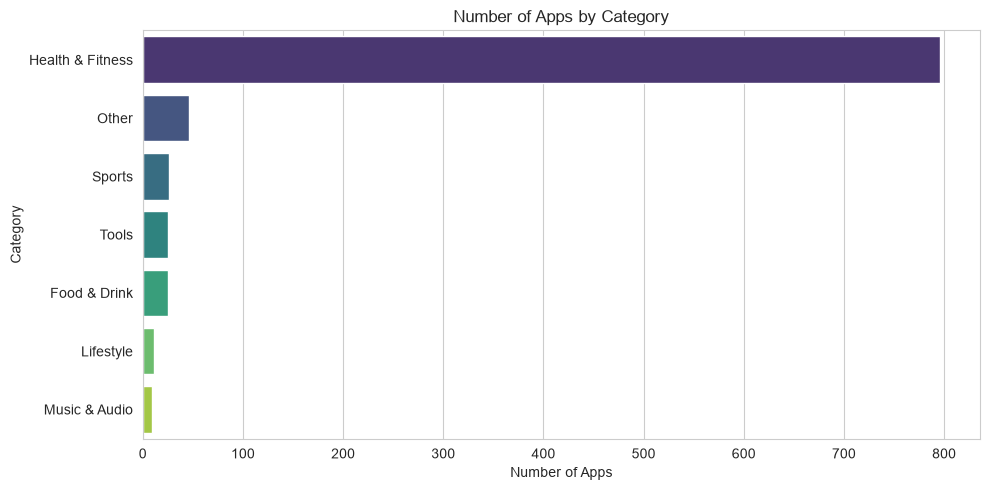

In [127]:
plt.figure(figsize=(10, 5))
category_counts = apps_clean['category_grouped'].value_counts()
sns.barplot(
    x=category_counts.values, 
    y=category_counts.index, 
    hue=category_counts.index, 
    palette='viridis', 
    legend=False
)

plt.title('Number of Apps by Category')
plt.xlabel('Number of Apps')
plt.ylabel('Category')
plt.tight_layout()

plt.savefig('../report/screenshots/category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.3 Rating Distribution — how good are fitness apps overall?

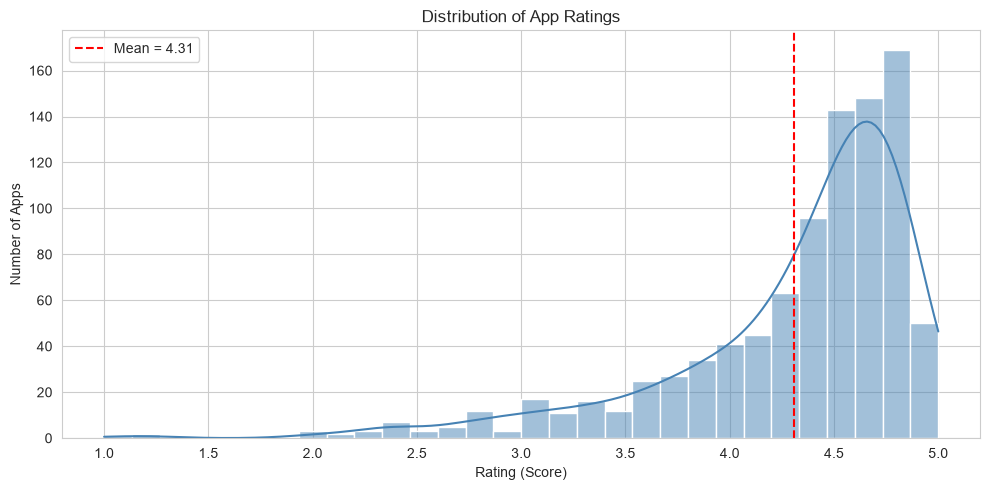

In [128]:
plt.figure(figsize=(10, 5))
sns.histplot(apps_clean['score'], bins=30, kde=True, color='steelblue')
plt.axvline(apps_clean['score'].mean(), color='red', linestyle='--',
            label=f"Mean = {apps_clean['score'].mean():.2f}")
plt.title('Distribution of App Ratings')
plt.xlabel('Rating (Score)')
plt.ylabel('Number of Apps')
plt.legend()
plt.tight_layout()
plt.savefig('../report/screenshots/rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.4 Free vs. Paid — does pricing model relate to rating?

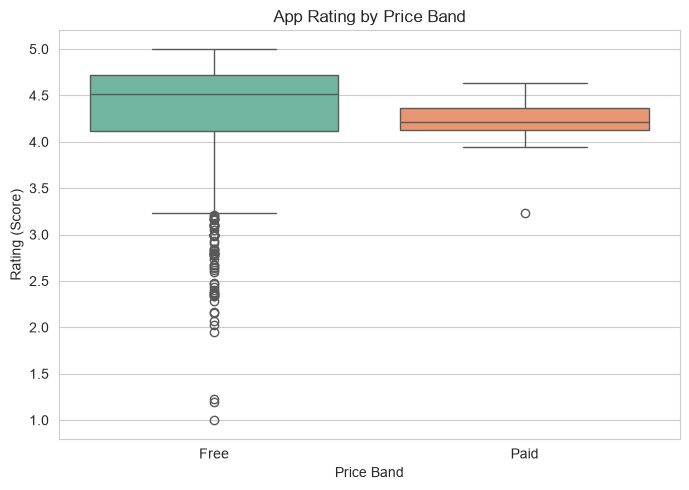

                mean    median  count
price_band                           
Free        4.311162  4.520000    930
Paid        4.163204  4.212441      8


In [129]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=apps_clean, x='price_band', y='score', hue='price_band', palette='Set2', legend=False)
plt.title('App Rating by Price Band')
plt.xlabel('Price Band')
plt.ylabel('Rating (Score)')
plt.tight_layout()
plt.savefig('../report/screenshots/price_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()

print(apps_clean.groupby('price_band')['score'].agg(['mean', 'median', 'count']))


### 6.5 Install Tier vs. Rating — do bigger apps perform better?

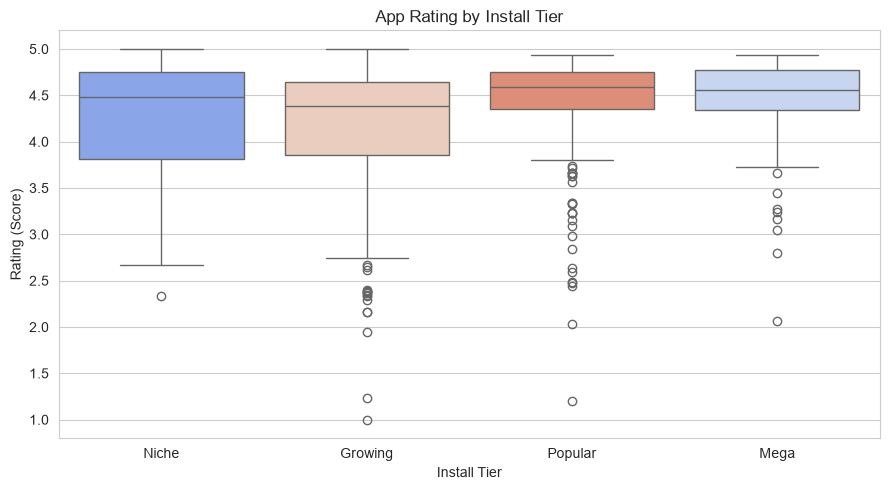

                  mean    median  count
install_tier                           
Niche         4.247160  4.486364     78
Growing       4.174506  4.386667    413
Popular       4.447063  4.592768    328
Mega          4.442865  4.560482    119


In [130]:
tier_order = ['Niche', 'Growing', 'Popular', 'Mega']
plt.figure(figsize=(9, 5))
sns.boxplot(data=apps_clean, x='install_tier', y='score', order=tier_order, palette='coolwarm', hue='install_tier', legend=False)
plt.title('App Rating by Install Tier')
plt.xlabel('Install Tier')
plt.ylabel('Rating (Score)')
plt.tight_layout()
plt.savefig('../report/screenshots/install_tier_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()

print(apps_clean.groupby('install_tier')['score'].agg(['mean', 'median', 'count']).reindex(tier_order))


### 6.6 Update Recency vs. Rating — does active maintenance correlate with trust?

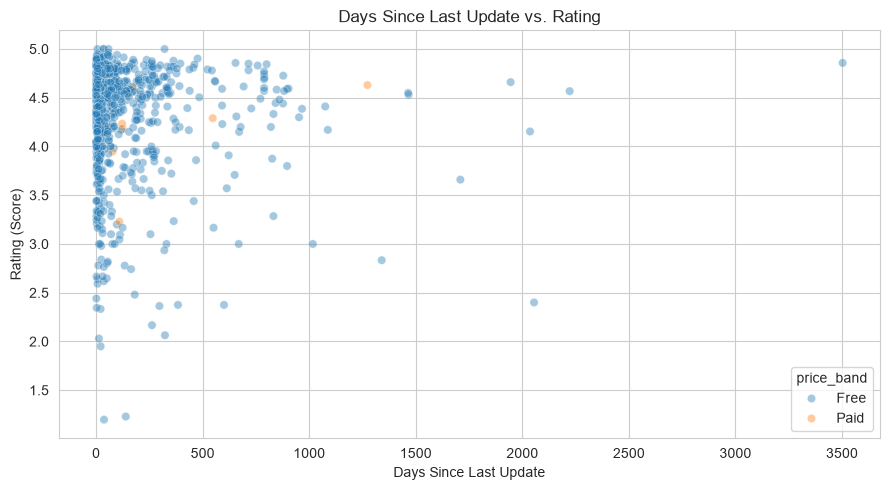

In [131]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=apps_clean, x='days_since_update', y='score', alpha=0.4, hue='price_band')
plt.title('Days Since Last Update vs. Rating')
plt.xlabel('Days Since Last Update')
plt.ylabel('Rating (Score)')
plt.tight_layout()
plt.savefig('../report/screenshots/update_recency_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.7 Outlier Detection — Installs (log scale) by Rating Tier

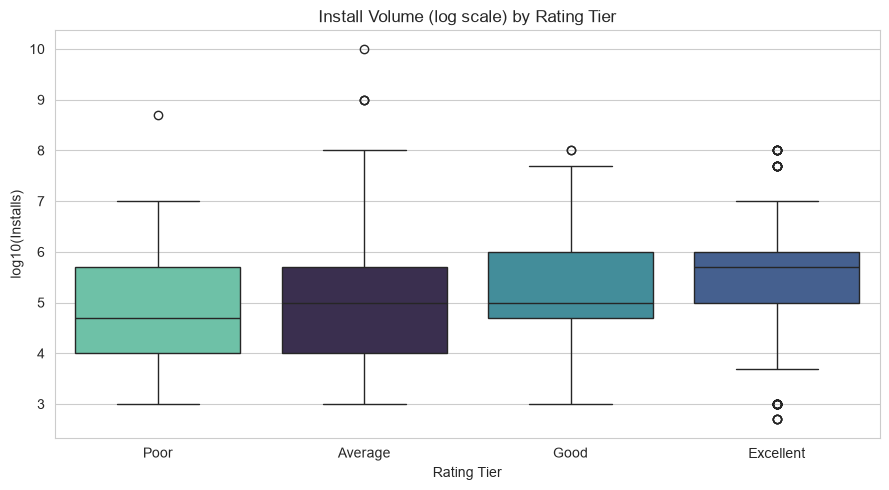

In [132]:
plt.figure(figsize=(9, 5))
apps_clean['log_installs'] = np.log10(apps_clean['minInstalls'] + 1)
tier_rating_order = ['Poor', 'Average', 'Good', 'Excellent']
sns.boxplot(data=apps_clean, x='rating_tier', y='log_installs', order=tier_rating_order, palette='mako', hue='rating_tier', legend=False)
plt.title('Install Volume (log scale) by Rating Tier')
plt.xlabel('Rating Tier')
plt.ylabel('log10(Installs)')
plt.tight_layout()
plt.savefig('../report/screenshots/installs_by_rating_tier.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.8 Correlation Heatmap — numeric feature relationships

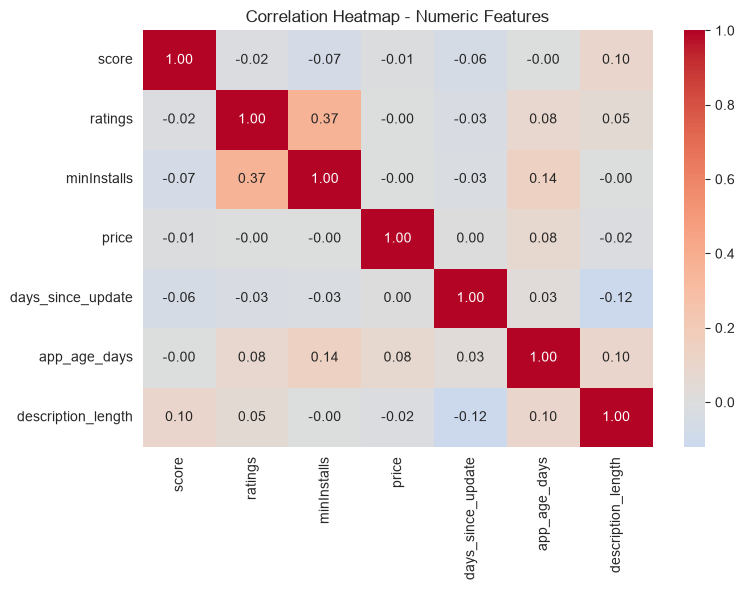

In [133]:
numeric_cols = ['score', 'ratings', 'minInstalls', 'price',
                 'days_since_update', 'app_age_days', 'description_length']
corr = apps_clean[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - Numeric Features')
plt.tight_layout()
plt.savefig('../report/screenshots/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.9 Ads & In-App Purchases — do monetization signals relate to rating?

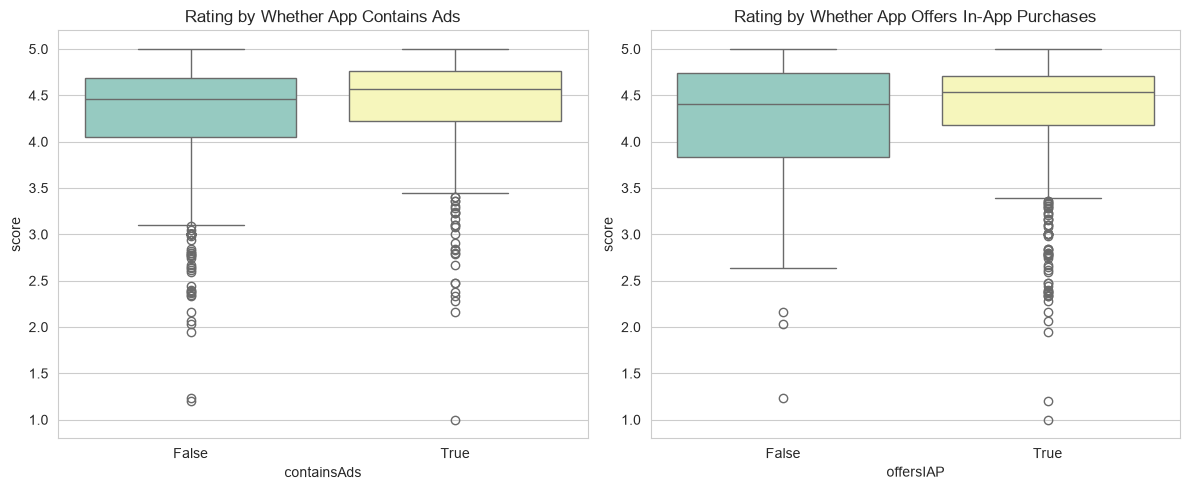

In [134]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=apps_clean, x='containsAds', y='score', ax=axes[0], hue='containsAds', palette='Set3', legend=False)
axes[0].set_title('Rating by Whether App Contains Ads')

sns.boxplot(data=apps_clean, x='offersIAP', y='score', ax=axes[1], hue='offersIAP', palette='Set3', legend=False)
axes[1].set_title('Rating by Whether App Offers In-App Purchases')

plt.tight_layout()
plt.savefig('../report/screenshots/ads_iap_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.10 Key EDA Takeaways

-Rating distribution is strongly left-skewed toward high ratings (mean 4.31) — most fitness apps that survive on the Play Store are decently rated; genuinely bad apps are rare in this cleaned set.
-Correlation heatmap confirms nothing here is strongly correlated with score — the highest correlation with rating is description_length at just 0.10, and everything else is near zero. This is actually a useful, honest finding: no single metadata field strongly predicts rating on its own, which sets up your modeling phase nicely (clustering to find combinations of traits will be more revealing than looking at single variables).
-Days since update vs. rating visually confirms the near-zero correlation — ratings are scattered across the full range regardless of recency.
-Install tier vs. rating confirms the "Popular" sweet-spot pattern we discussed.

- Which category dominates the fitness app market, and does that concentration
  make competitive sense?
- Is there a meaningful rating difference between Free and Paid apps?
- Does install volume (popularity) correlate with quality (rating), or are they independent?
- Does update recency show any relationship with rating — is "actively maintained" a trust signal?
- Do ads or in-app purchases appear to hurt or help ratings?


## 7. Save Cleaned Datasets

These feed directly into the modeling notebook (`03_modeling.ipynb`).


In [123]:

apps_clean.to_csv('../data/processed/cleaned_apps.csv', index=False)
reviews_clean.to_csv('../data/processed/cleaned_reviews.csv', index=False)

print(f"Saved cleaned_apps.csv -> {apps_clean.shape[0]} rows, {apps_clean.shape[1]} columns")
print(f"Saved cleaned_reviews.csv -> {reviews_clean.shape[0]} rows, {reviews_clean.shape[1]} columns")


Saved cleaned_apps.csv -> 938 rows, 23 columns
Saved cleaned_reviews.csv -> 32592 rows, 8 columns
